# Benchmarking Quantum Circuit Simulators: One Circuit, Five Backends

A quantum *simulator* is an ordinary classical program that pretends to be a quantum computer. There are many to choose from, and they are not equally fast. In this notebook we take **one circuit**, run it on **five simulators** (Qiskit Aer, Cirq, PennyLane, Qibo, Amazon Braket), and look at four things: how the time scales with **qubit count** and **depth**, the **memory wall** behind it all, and whether compiling with **UCC** first makes it faster.

Everything runs locally on CPU.

## Why simulating is hard

A classical computer stores $n$ qubits as a **statevector** of $2^n$ complex numbers. Every extra qubit doubles it, and every gate updates the whole thing, so time grows like

$$\text{time} \approx O(g \cdot 2^n).$$

## Setup

```bash
pip install qiskit qiskit-aer cirq pennylane qibo amazon-braket-sdk ucc matplotlib numpy
```

We pin every backend to one thread (before NumPy loads) so we compare simulators, not core counts.

In [1]:
import os
for var in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ[var] = "1"

import time, statistics, tracemalloc, warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
warnings.filterwarnings("ignore")

seed = 1234
warmups = 1
repeats = 3

## One circuit for everyone

We describe the circuit once as a neutral list of tuples, and let each library translate it. `("rx", 3, 1.57)` rotates qubit 3 about X; `("cx", 0, 1)` is a CNOT.

In [2]:
def build_gate_list(num_qubits, depth):
    rng = np.random.default_rng(seed)
    gates = []
    for _ in range(depth):
        for q in range(num_qubits):
            gates.append(("rx", q, float(rng.uniform(0, 2 * np.pi))))
            gates.append(("rz", q, float(rng.uniform(0, 2 * np.pi))))
        for q in range(num_qubits - 1):
            gates.append(("cx", q, q + 1))
    return gates

## One runner per simulator

In [3]:
def run_qiskit_aer(gates, num_qubits):
    from qiskit import QuantumCircuit
    from qiskit_aer import AerSimulator
    circ = QuantumCircuit(num_qubits)
    for g in gates:
        if g[0]=="rx": circ.rx(g[2], g[1])
        elif g[0]=="ry": circ.ry(g[2], g[1])
        elif g[0]=="rz": circ.rz(g[2], g[1])
        elif g[0]=="cx": circ.cx(g[1], g[2])
    circ.save_statevector()
    sim = AerSimulator(method="statevector")
    return lambda: sim.run(circ).result()

def run_cirq(gates, num_qubits):
    import cirq
    qs = cirq.LineQubit.range(num_qubits); circ = cirq.Circuit()
    for g in gates:
        if g[0]=="rx": circ.append(cirq.rx(g[2]).on(qs[g[1]]))
        elif g[0]=="ry": circ.append(cirq.ry(g[2]).on(qs[g[1]]))
        elif g[0]=="rz": circ.append(cirq.rz(g[2]).on(qs[g[1]]))
        elif g[0]=="cx": circ.append(cirq.CNOT(qs[g[1]], qs[g[2]]))
    sim = cirq.Simulator()
    return lambda: sim.simulate(circ)

def run_pennylane(gates, num_qubits):
    import pennylane as qml
    dev = qml.device("default.qubit", wires=num_qubits)
    def circuit():
        for g in gates:
            if g[0]=="rx": qml.RX(g[2], wires=g[1])
            elif g[0]=="ry": qml.RY(g[2], wires=g[1])
            elif g[0]=="rz": qml.RZ(g[2], wires=g[1])
            elif g[0]=="cx": qml.CNOT(wires=[g[1], g[2]])
        return qml.state()
    return lambda: qml.QNode(circuit, dev)()

def run_qibo(gates, num_qubits):
    from qibo import Circuit, gates as G, set_backend
    set_backend("numpy")
    circ = Circuit(num_qubits)
    for g in gates:
        if g[0]=="rx": circ.add(G.RX(g[1], theta=g[2]))
        elif g[0]=="ry": circ.add(G.RY(g[1], theta=g[2]))
        elif g[0]=="rz": circ.add(G.RZ(g[1], theta=g[2]))
        elif g[0]=="cx": circ.add(G.CNOT(g[1], g[2]))
    return lambda: circ()

def run_braket(gates, num_qubits):
    from braket.circuits import Circuit
    from braket.devices import LocalSimulator
    circ = Circuit()
    for g in gates:
        if g[0]=="rx": circ.rx(g[1], g[2])
        elif g[0]=="ry": circ.ry(g[1], g[2])
        elif g[0]=="rz": circ.rz(g[1], g[2])
        elif g[0]=="cx": circ.cnot(g[1], g[2])
    circ.state_vector()
    dev = LocalSimulator("braket_sv")
    return lambda: dev.run(circ).result()

simulators = {"qiskit_aer": run_qiskit_aer, "cirq": run_cirq,
              "pennylane": run_pennylane, "qibo": run_qibo, "braket": run_braket}

## Do the simulators agree?

Before timing, we prove all five compute the *same* state. The libraries number qubits differently (Qiskit puts qubit 0 last; the others put it first), so we reverse the qubit axis to line them up, then compare with the fidelity $|\langle a|b\rangle|^2$, which is 1 for matching states.

In [4]:
def to_qiskit_order(state, name, n):
    state = np.asarray(state).ravel().astype(complex)
    if name != "qiskit_aer":
        state = state.reshape([2]*n).transpose(range(n-1, -1, -1)).ravel()
    return state / np.linalg.norm(state)

def final_state(name, gates, n):
    if name == "qiskit_aer":
        from qiskit import QuantumCircuit
        from qiskit_aer import AerSimulator
        qc = QuantumCircuit(n)
        for g in gates:
            if g[0]=="rx": qc.rx(g[2], g[1])
            elif g[0]=="rz": qc.rz(g[2], g[1])
            elif g[0]=="cx": qc.cx(g[1], g[2])
        qc.save_statevector()
        s = AerSimulator(method="statevector").run(qc).result().get_statevector().data
    elif name == "cirq":
        import cirq
        qs = cirq.LineQubit.range(n); circ = cirq.Circuit()
        for g in gates:
            if g[0]=="rx": circ.append(cirq.rx(g[2]).on(qs[g[1]]))
            elif g[0]=="rz": circ.append(cirq.rz(g[2]).on(qs[g[1]]))
            elif g[0]=="cx": circ.append(cirq.CNOT(qs[g[1]], qs[g[2]]))
        s = cirq.Simulator().simulate(circ).final_state_vector
    elif name == "pennylane":
        import pennylane as qml
        dev = qml.device("default.qubit", wires=n)
        def f():
            for g in gates:
                if g[0]=="rx": qml.RX(g[2], wires=g[1])
                elif g[0]=="rz": qml.RZ(g[2], wires=g[1])
                elif g[0]=="cx": qml.CNOT(wires=[g[1], g[2]])
            return qml.state()
        s = qml.QNode(f, dev)()
    elif name == "qibo":
        from qibo import Circuit, gates as G, set_backend
        set_backend("numpy"); circ = Circuit(n)
        for g in gates:
            if g[0]=="rx": circ.add(G.RX(g[1], theta=g[2]))
            elif g[0]=="rz": circ.add(G.RZ(g[1], theta=g[2]))
            elif g[0]=="cx": circ.add(G.CNOT(g[1], g[2]))
        s = circ().state()
    elif name == "braket":
        from braket.circuits import Circuit
        from braket.devices import LocalSimulator
        circ = Circuit()
        for g in gates:
            if g[0]=="rx": circ.rx(g[1], g[2])
            elif g[0]=="rz": circ.rz(g[1], g[2])
            elif g[0]=="cx": circ.cnot(g[1], g[2])
        circ.state_vector()
        s = LocalSimulator("braket_sv").run(circ).result().values[0]
    return to_qiskit_order(s, name, n)

g = build_gate_list(8, 5)
ref = final_state("qiskit_aer", g, 8)
for name in simulators:
    fid = abs(np.vdot(ref, final_state(name, g, 8)))**2
    print("  %-11s fidelity vs qiskit_aer = %.12f" % (name, fid))
print("  -> all five agree")

  qiskit_aer  fidelity vs qiskit_aer = 1.000000000000


  cirq        fidelity vs qiskit_aer = 1.000000000000


[Qibo 0.3.4|INFO|2026-06-21 21:08:28]: Using numpy backend on /CPU:0


  pennylane   fidelity vs qiskit_aer = 1.000000000000
  qibo        fidelity vs qiskit_aer = 1.000000000000


  braket      fidelity vs qiskit_aer = 1.000000000000
  -> all five agree


## Timing fairly

Two warm-up rounds are thrown away (one-time costs), then we take the median of several timed runs.

In [5]:
def time_run(execute):
    for _ in range(warmups):
        execute()
    samples = []
    for _ in range(repeats):
        start = time.perf_counter(); execute(); samples.append(time.perf_counter() - start)
    return statistics.median(samples)

def benchmark_point(num_qubits, depth):
    gates = build_gate_list(num_qubits, depth)
    row = {"qubits": num_qubits, "depth": depth}
    for name, builder in simulators.items():
        row[name] = time_run(builder(gates, num_qubits))
    return row

## Scaling with qubit count (depth = 10)

[Qibo 0.3.4|INFO|2026-06-21 21:08:28]: Using numpy backend on /CPU:0


[Qibo 0.3.4|INFO|2026-06-21 21:08:29]: Using numpy backend on /CPU:0


[Qibo 0.3.4|INFO|2026-06-21 21:08:31]: Using numpy backend on /CPU:0


[Qibo 0.3.4|INFO|2026-06-21 21:08:33]: Using numpy backend on /CPU:0


[Qibo 0.3.4|INFO|2026-06-21 21:08:43]: Using numpy backend on /CPU:0


  qubits qiskit_aer  cirq        pennylane   qibo        braket     
  10        0.0075s    0.0215s    0.0250s    0.0060s    0.1098s
  12        0.0117s    0.0283s    0.0344s    0.0121s    0.1186s
  14        0.0277s    0.0414s    0.0541s    0.0355s    0.1585s
  16        0.0768s    0.0799s    0.1308s    0.1428s    0.1860s
  18        0.3389s    0.3458s    1.3568s    1.4172s    0.4098s


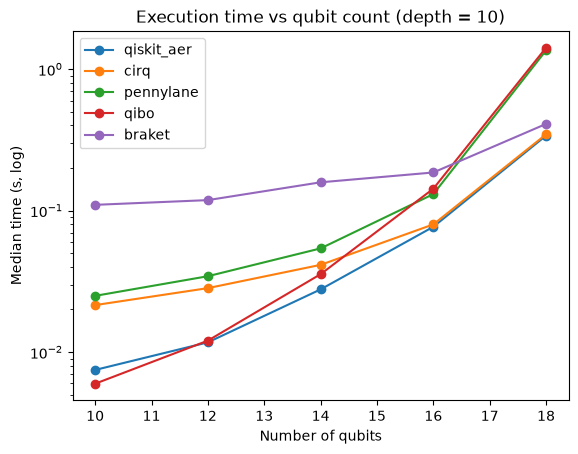

In [6]:
qubit_rows = [benchmark_point(n, 10) for n in [10, 12, 14, 16, 18]]
print("  qubits " + " ".join("%-11s" % n for n in simulators))
for r in qubit_rows:
    print("  %-6d " % r["qubits"] + " ".join("%9.4fs" % r[n] for n in simulators))
x = [r["qubits"] for r in qubit_rows]
for name in simulators: plt.plot(x, [r[name] for r in qubit_rows], marker="o", label=name)
plt.yscale("log"); plt.xlabel("Number of qubits"); plt.ylabel("Median time (s, log)")
plt.title("Execution time vs qubit count (depth = 10)"); plt.legend(); plt.show()

## Scaling with circuit depth (qubits = 12)

[Qibo 0.3.4|INFO|2026-06-21 21:08:52]: Using numpy backend on /CPU:0


[Qibo 0.3.4|INFO|2026-06-21 21:08:52]: Using numpy backend on /CPU:0


[Qibo 0.3.4|INFO|2026-06-21 21:08:53]: Using numpy backend on /CPU:0


[Qibo 0.3.4|INFO|2026-06-21 21:08:56]: Using numpy backend on /CPU:0


  depth  qiskit_aer  cirq        pennylane   qibo        braket     
  5         0.0054s    0.0134s    0.0176s    0.0060s    0.0658s
  10        0.0115s    0.0295s    0.0494s    0.0121s    0.1217s
  20        0.0227s    0.0544s    0.0675s    0.0262s    0.2413s
  40        0.0413s    0.1098s    0.1522s    0.0488s    0.6631s


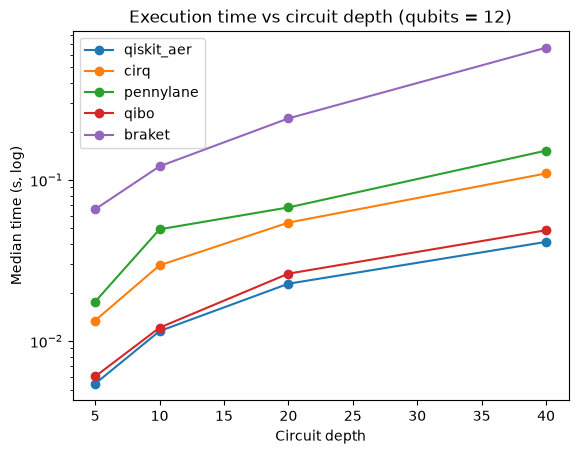

In [7]:
depth_rows = [benchmark_point(12, d) for d in [5, 10, 20, 40]]
print("  depth  " + " ".join("%-11s" % n for n in simulators))
for r in depth_rows:
    print("  %-6d " % r["depth"] + " ".join("%9.4fs" % r[n] for n in simulators))
x = [r["depth"] for r in depth_rows]
for name in simulators: plt.plot(x, [r[name] for r in depth_rows], marker="o", label=name)
plt.yscale("log"); plt.xlabel("Circuit depth"); plt.ylabel("Median time (s, log)")
plt.title("Execution time vs circuit depth (qubits = 12)"); plt.legend(); plt.show()

## The memory wall

The deeper reason simulation is hard is memory: a statevector is $2^n$ complex numbers, 16 bytes each.

  10 qubits ->       0.0 MB
  14 qubits ->       0.3 MB
  18 qubits ->       4.2 MB
  22 qubits ->      67.1 MB
  24 qubits ->     268.4 MB


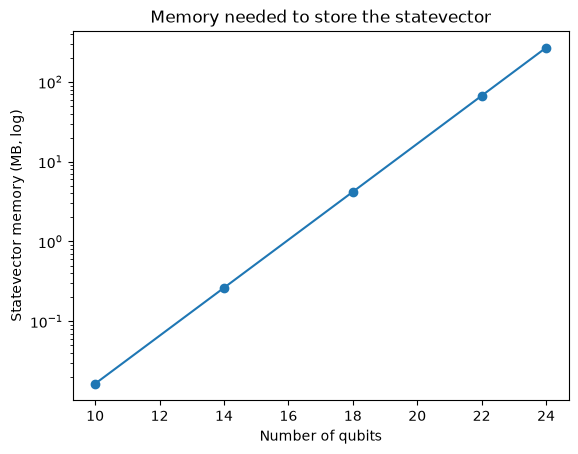

In [8]:
def statevector_memory(num_qubits):
    tracemalloc.start()
    state = np.zeros(2 ** num_qubits, dtype=complex); state[0] = 1.0
    _, peak = tracemalloc.get_traced_memory(); tracemalloc.stop(); del state
    return peak / 1e6

mem = [(n, statevector_memory(n)) for n in [10, 14, 18, 22, 24]]
for n, mb in mem: print("  %2d qubits -> %9.1f MB" % (n, mb))
plt.plot([n for n,_ in mem], [mb for _,mb in mem], marker="o")
plt.yscale("log"); plt.xlabel("Number of qubits"); plt.ylabel("Statevector memory (MB, log)")
plt.title("Memory needed to store the statevector"); plt.show()

## Does compiling with UCC help?

A compiler can rewrite a circuit with fewer gates, which means less work for the simulator. We compile a Quantum Volume circuit with UCC and compare the gate count.

  qubits  raw -> compiled   (fewer)


  12      1872 -> 1626   (13%)
  14      2548 -> 2252   (12%)
  16      3328 -> 3090   ( 7%)


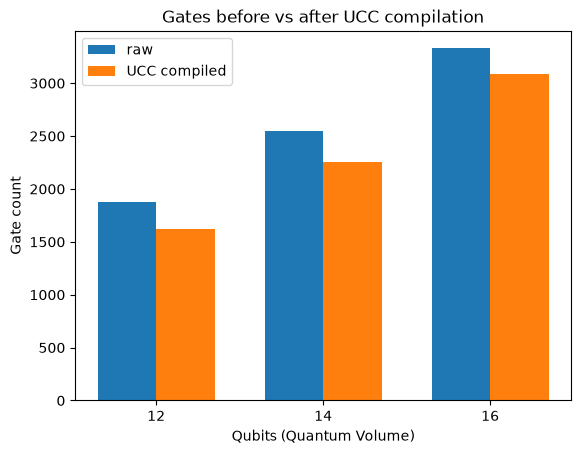

In [9]:
from qiskit import transpile
from qiskit.circuit.library import quantum_volume
from ucc import compile as ucc_compile

def gate_count(circuit):
    flat = transpile(circuit, basis_gates=["rz", "ry", "cx"], optimization_level=0)
    return len(flat.data)

print("  qubits  raw -> compiled   (fewer)")
labels, raw, comp = [], [], []
for n in [12, 14, 16]:
    qv = quantum_volume(n, seed=seed)
    r, c_ = gate_count(qv), gate_count(ucc_compile(qv))
    labels.append(str(n)); raw.append(r); comp.append(c_)
    print("  %2d      %4d -> %4d   (%2d%%)" % (n, r, c_, round(100*(1-c_/r))))
pos = range(len(labels)); w = 0.35
plt.bar([p-w/2 for p in pos], raw, w, label="raw")
plt.bar([p+w/2 for p in pos], comp, w, label="UCC compiled")
plt.xticks(list(pos), labels); plt.xlabel("Qubits (Quantum Volume)"); plt.ylabel("Gate count")
plt.title("Gates before vs after UCC compilation"); plt.legend(); plt.show()

## Predicting the wall

We have a formula, $\text{time} \approx C \cdot g \cdot 2^n$, and measurements. Fitting one to the other gives $C$ for each simulator, and then we can predict where each crosses 1 second, 1 minute, and 16 GB of memory.

In [10]:
def gates_in_circuit(n, depth): return depth * (2*n + (n-1))

work = np.array([gates_in_circuit(r["qubits"], 10) * 2**r["qubits"] for r in qubit_rows])
print("  %-11s %-9s %-6s %-8s %-8s %-8s" % ("simulator","C","R^2","1 sec","1 min","16GB"))
for name in simulators:
    T = np.array([r[name] for r in qubit_rows])
    C, b = np.polyfit(work, T, 1)
    r2 = 1 - np.sum((T-(C*work+b))**2)/np.sum((T-T.mean())**2)
    def q_for(target):
        for n in range(8, 41):
            if C*gates_in_circuit(n,10)*2**n + b >= target: return n
        return 40
    oom = next(n for n in range(8,60) if 2**n*16 > 16e9)
    print("  %-11s %.2e  %.3f  %-8d %-8d %-8d" % (name, C, r2, q_for(1), q_for(60), oom))

  simulator   C         R^2    1 sec    1 min    16GB    
  qiskit_aer  2.38e-09  1.000  20       26       30      
  cirq        2.32e-09  0.997  20       26       30      
  pennylane   9.74e-09  0.981  18       24       30      
  qibo        1.03e-08  0.985  18       24       30      
  braket      2.07e-09  0.988  20       26       30      


## What we learned

- **No simulator wins everywhere.** Qiskit Aer and Cirq scale best; PennyLane `default.qubit` and Qibo (NumPy) climb steeply past 16 qubits; Braket carries a fixed overhead.
- **Depth is cheap, qubits are expensive.** Time grows linearly with depth but exponentially with qubits, matching $O(g \cdot 2^n)$.
- **Memory is the real wall.** $2^n$ amplitudes mean 30 qubits ~ 16 GB, 40 qubits ~ 16 TB.
- **UCC removes gates** (reproducibly), which gives a modest, circuit-dependent simulation speedup.

**Caveats:** one laptop, single thread; default (not fastest) backends; Braket timing includes SDK overhead. A good benchmark says so out loud.

## References

[1] [UCC](https://github.com/unitaryfoundation/ucc) and [ucc-bench](https://github.com/unitaryfoundation/ucc-bench), Unitary Foundation.
[2] Javadi-Abhari, A., et al. (2024). Quantum computing with Qiskit. arXiv:2405.08810.
[3] Bergholm, V., et al. (2018). PennyLane. arXiv:1811.04968.
[4] Efthymiou, S., et al. (2021). Qibo. Quantum Science and Technology, 7(1), 015018.